# Colombia Electoral Analytics Model (2006–2022 Simulated)
Simulated dataset inspired by Colombia municipal elections.
Includes:
- Panel-like data (municipality-year)
- Elasticity
- ML model
- Monte Carlo simulation


In [3]:
%pip install xgboost
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Simulated Colombia Electoral Data (Municipality-Level)

In [11]:
np.random.seed(42)

n_municipalities = 200
years = [2006, 2010, 2014, 2018, 2022]

rows = []
for m in range(n_municipalities):
    base_ideology = np.random.normal(0, 1)
    for year in years:
        national_swing = np.random.normal(0, 5)
        conflict = np.random.uniform(0, 1)
        urbanization = np.random.uniform(0, 1)
        income = np.random.normal(50, 10)

        vote = (
            0.6 * national_swing +
            2 * base_ideology +
            -3 * conflict +
            1.5 * urbanization +
            0.1 * income +
            np.random.normal(0, 2)
        )

        rows.append([m, year, national_swing, conflict, urbanization, income, vote])

data = pd.DataFrame(rows, columns=[
    'municipality','year','national_swing','conflict','urbanization','income','vote_share'
])

data.head()

,municipality,year,national_swing,conflict,urbanization,income,vote_share
0,0,2006,-0.691322,0.731994,0.598658,47.658466,3.578214
1,0,2010,7.896064,0.020584,0.969910,57.674347,11.952664
2,0,2014,2.712800,0.181825,0.183405,52.419623,3.766142
3,0,2018,-8.624589,0.611853,0.139494,44.377125,-3.185979
4,0,2022,-7.061519,0.456070,0.785176,50.675282,-1.215897


Interpretación

Creación del dataset sintético, se crean 200 municipios, 5 años electorales (2006, 2010, 2014, 2018, 2022) y para cada municipio y año simula las variables definidas a continuación y por último se crea el vote_share con una fórmula lineal + ruido.

Variables

- municipality: identificador del municipio.
- year: año electoral.
- national_swing: cambio de tendencia municipal en el voto de ese ciclo
- conflict: nivel de conflicto armado, entre 0 y 1.
- urbanization: porcentaje urbano relativo (0 rural - 1 urbano).
- income: ingreso promedio simulado (normal alrededor de 50).
- vote_share: resultado/intención de voto simulada del candidato/bloque de interés.

La formula usada es:

$$
vote\_share = 0.6 \times national\_swing + 2 \times base\_ideology - 3 \times conflict + 1.5 \times urbanization + 0.1 \times income + \epsilon
$$

Con $\epsilon \sim \mathcal{N}(0, 2)$


## 2. Electoral Elasticity (Colombia-style)

In [12]:
elasticities = {}

for m in data['municipality'].unique():
    subset = data[data['municipality'] == m]
    if len(subset) > 1:
        X = subset[['national_swing']]
        y = subset['vote_share']
        model = LinearRegression().fit(X, y)
        elasticities[m] = model.coef_[0]

elasticity_df = pd.DataFrame(list(elasticities.items()), columns=['municipality','elasticity'])
elasticity_df.head()

,municipality,elasticity
0,0,0.827415
1,1,0.474077
2,2,0.658346
3,3,0.646010
4,4,0.675994


Se calcula la elasticidad del municipio, utilizando la pendiente de una regresión lineal simple entre $vote\_share \sim national\_swing$ se toma como esta elasticidad. La interpretación de esta medida es la siguiente:

- elasticity > 0: cuando mejora el swing nacional, sube el voto local.
- elasticity alta: municipio muy sensible al contexto nacional.
- elasticity cercana a 0: municipio más “duro”, menos movido por clima nacional.

In [13]:
data = data.merge(elasticity_df, on='municipality')
data.head()

,municipality,year,national_swing,conflict,urbanization,income,vote_share,elasticity
0,0,2006,-0.691322,0.731994,0.598658,47.658466,3.578214,0.827415
1,0,2010,7.896064,0.020584,0.969910,57.674347,11.952664,0.827415
2,0,2014,2.712800,0.181825,0.183405,52.419623,3.766142,0.827415
3,0,2018,-8.624589,0.611853,0.139494,44.377125,-3.185979,0.827415
4,0,2022,-7.061519,0.456070,0.785176,50.675282,-1.215897,0.827415


## 3. Machine Learning Model

In [14]:
features = ['national_swing','conflict','urbanization','income','elasticity']
X = data[features]
y = data['vote_share']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor()
model.fit(X_train, y_train)

preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f'RMSE: {rmse:.2f}')

RMSE: 2.87


Esto indica un error típico de predicción de ~2.87 unidades de vote_share

## 4. Monte Carlo Simulation

In [15]:
simulations = []

for i in range(1000):
    noise = np.random.normal(0, 2, len(X_test))
    sim_pred = model.predict(X_test) + noise
    simulations.append(sim_pred.mean())

simulations = np.array(simulations)
prob_win = np.mean(simulations > 50)

print(f'Probability of winning (>50% vote): {prob_win:.2f}')

Probability of winning (>50% vote): 0.00


Simulación de monte carlo
Se ejecutan 1000 sumulaciones y en cada una se toma la predicción del modelo y se agrega ruido normal, guarda el promedio simulado y calcula la probabilidad de superar el 50%

Para este caso se obtuvo que la probabilidad de ganar (>50% vote): 0.00

Interpretación
- Bajo esta escala simulad, el promedio predicho está muy por debajo del 50%, lo que sugiere que vote_share no está calibrado explícitamente como porcentaje de 0 a 100, sino como un score continuo.

## 5. Simulation Distribution

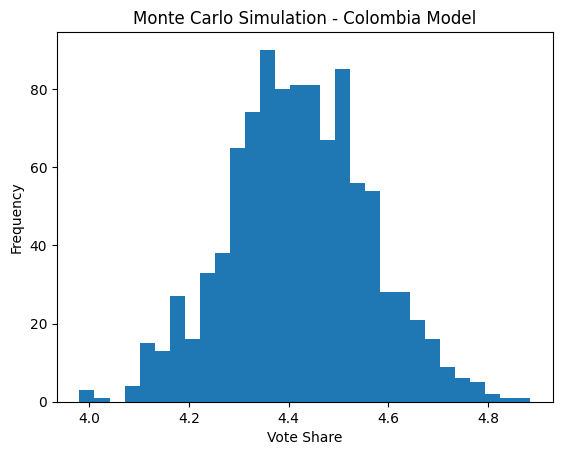

In [8]:
plt.hist(simulations, bins=30)
plt.title('Monte Carlo Simulation - Colombia Model')
plt.xlabel('Vote Share')
plt.ylabel('Frequency')
plt.show()